<a href="https://colab.research.google.com/github/Zuhdiaja/244107020017_Machine_Learning/blob/main/JS04/Quiz/kmeans_Euclidean_Distance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Euclidean Distance

In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.feature_selection import VarianceThreshold

import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/ML 2026/quiz/dataset_B_05_2020 (1).csv")

print("Shape dataset:", df.shape)
print("Jumlah data:", df.shape[0])
print("Jumlah kolom:", df.shape[1])

Shape dataset: (11430, 89)
Jumlah data: 11430
Jumlah kolom: 89


In [ ]:
urls = df["url"].copy()
labels = df["status"].copy()

# Hanya fitur numerik
X = df.drop(columns=["url", "status"])
X = X.select_dtypes(include=np.number)

print("\nShape fitur numerik:", X.shape)
df.head()


Shape fitur numerik: (11430, 87)


,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,...,1,0,0,14,4004,5828815,0,1,0,phishing
3,http://rgipt.ac.in,18,11,0,2,0,0,0,0,0,...,1,0,0,62,-1,107721,0,0,3,legitimate
4,http://www.iracing.com/tracks/gateway-motorspo...,55,15,0,2,2,0,0,0,0,...,0,1,0,224,8175,8725,0,0,6,legitimate


In [ ]:
print("Total missing value:", X.isna().sum().sum())

X = X.fillna(X.median())


Total missing value: 0


In [ ]:
selector = VarianceThreshold(threshold=0)

X_selected = selector.fit_transform(X)

selected_features = X.columns[
    selector.get_support()
]

X_selected = pd.DataFrame(
    X_selected,
    columns=selected_features
)

print("\nSetelah menghapus fitur konstan:")
print("Shape:", X_selected.shape)

print("Jumlah fitur:", len(selected_features))


Setelah menghapus fitur konstan:
Shape: (11430, 81)
Jumlah fitur: 81


In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_selected)

print("\nSetelah StandardScaler:")
print("Shape:", X_scaled.shape)
df.head()


Setelah StandardScaler:
Shape: (11430, 81)


,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,...,1,0,0,14,4004,5828815,0,1,0,phishing
3,http://rgipt.ac.in,18,11,0,2,0,0,0,0,0,...,1,0,0,62,-1,107721,0,0,3,legitimate
4,http://www.iracing.com/tracks/gateway-motorspo...,55,15,0,2,2,0,0,0,0,...,0,1,0,224,8175,8725,0,0,6,legitimate


In [ ]:
print("BEFORE PREPROCESSING")
print(f"Bentuk data asli (df): {df.shape}")
# Menampilkan 3 baris awal dengan 5 kolom pertama dan 5 kolom terakhir
display(df.head(3))

print("AFTER PREPROCESSING")
print(f"Bentuk data siap klastering (X_scaled): {X_scaled.shape}")
# Mengubah array X_scaled kembali menjadi DataFrame untuk kemudahan visualisasi
df_after = pd.DataFrame(X_scaled, columns=selected_features)
display(df_after.head(3))

BEFORE PREPROCESSING
Bentuk data asli (df): (11430, 89)


,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,...,1,0,0,14,4004,5828815,0,1,0,phishing


AFTER PREPROCESSING
Bentuk data siap klastering (X_scaled): (11430, 81)


,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_eq,nb_underscore,...,empty_title,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank
0,-0.436327,-0.193964,-0.421020,0.379116,-0.477984,-0.142915,-0.387464,-0.197604,-0.293683,-0.295128,...,-0.377549,-1.860473,1.129194,-0.28037,-0.549299,-1.307594,-0.429340,6.978227,0.934264,0.320974
1,0.287067,0.177207,2.375182,-1.081136,-0.477984,-0.142915,-0.387464,-0.197604,-0.293683,-0.295128,...,-0.377549,0.537498,-0.885587,-0.28037,-0.510022,0.548471,-0.429340,-0.143303,0.934264,-0.467407
2,1.173224,2.682613,2.375182,1.109242,0.001174,-0.142915,2.356473,2.237556,2.711505,1.534217,...,-0.377549,0.537498,-0.885587,-0.28037,-0.587348,-0.018839,2.491612,-0.143303,0.934264,-1.255788


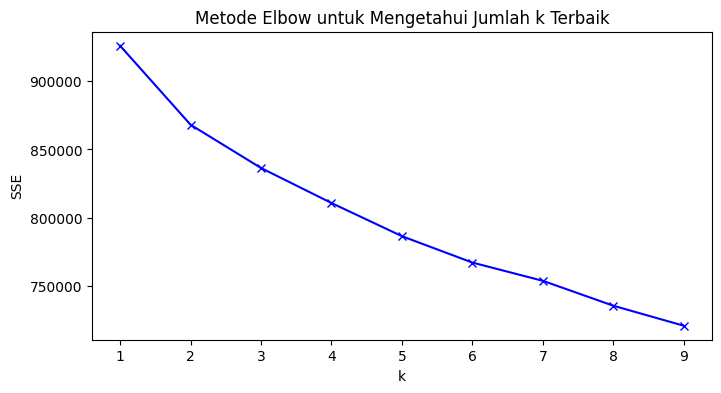

In [ ]:
# Implementasi Metode Elbow

# List nilai SSE
sse = []

# Cari k terbaik dari 1-10
K = range(1,10)

# Cek nilai SSE setiap k
for k in K:
 kmeanModel = KMeans(n_clusters=k, random_state=42, n_init=10)
 kmeanModel.fit(X_scaled)
 sse.append(kmeanModel.inertia_)


# Plotting the distortions
plt.figure(figsize=(8,4))
plt.plot(K, sse, "bx-")

plt.xlabel("k")
plt.ylabel("SSE")
plt.title("Metode Elbow untuk Mengetahui Jumlah k Terbaik")
plt.show()

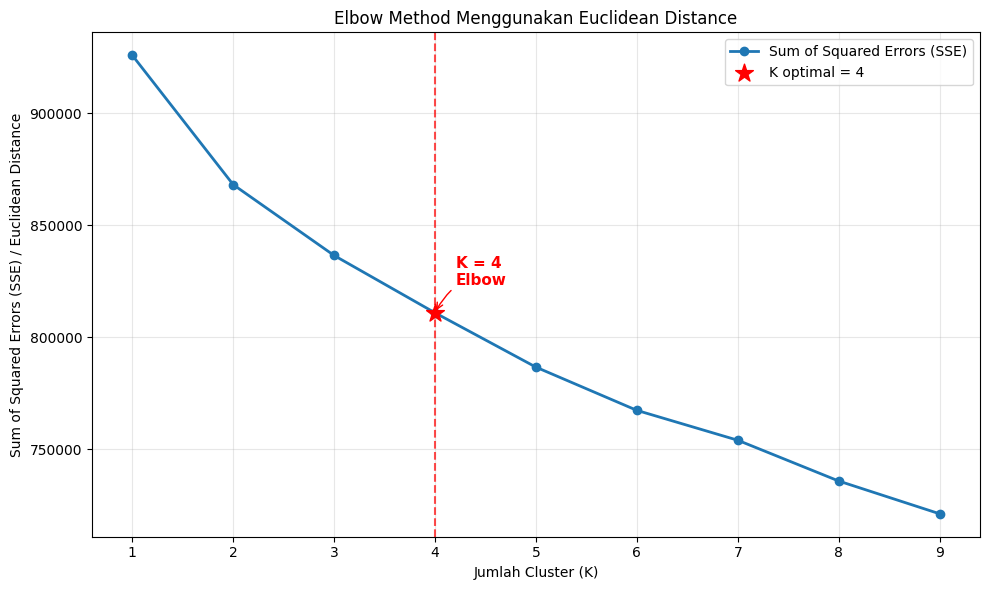

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from kneed import KneeLocator

# 1. Menghitung SSE untuk K 1 hingga 9
sse = []
K = range(1, 10)

for k in K:
    kmeanModel = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeanModel.fit(X_scaled) # Pastikan data Anda (X_scaled) sudah diload dan diskalakan
    sse.append(kmeanModel.inertia_)

# 2. Mencari K optimal dengan KneeLocator
kl = KneeLocator(K, sse, curve="convex", direction="decreasing")
optimal_k = kl.elbow

# Mencari indeks dari optimal_k di dalam list K untuk mendapatkan nilai Y (SSE) yang tepat
optimal_index = list(K).index(optimal_k)

# 3. Visualisasi dengan gaya kustom
plt.figure(figsize=(10, 6))

plt.plot(
    K,
    sse,
    marker="o",
    linewidth=2,
    color="tab:blue",
    label="Sum of Squared Errors (SSE)"
)

if optimal_k is not None:
    # Titik K optimal
    plt.scatter(
        optimal_k,
        sse[optimal_index],
        s=180,
        color="red",
        marker="*",
        zorder=5,
        label=f"K optimal = {optimal_k}"
    )

    # Garis vertikal
    plt.axvline(
        optimal_k,
        color="red",
        linestyle="--",
        alpha=0.7
    )

    # Label Anotasi
    plt.annotate(
        f"K = {optimal_k}\nElbow",
        xy=(
            optimal_k,
            sse[optimal_index]
        ),
        xytext=(15, 20), # Disesuaikan sedikit agar teks tidak tertabrak garis
        textcoords="offset points",
        fontsize=11,
        fontweight="bold",
        color="red",
        arrowprops=dict(arrowstyle="->", color="red", connectionstyle="arc3,rad=.2")
    )

plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("Sum of Squared Errors (SSE) / Euclidean Distance")
plt.title("Elbow Method Menggunakan Euclidean Distance")

plt.xticks(list(K))
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Cek Nilai SSE setiap k
for idx, sse_val in enumerate(sse, start=1):
    print(f'k={idx}; SSE={sse_val}')

k=1; SSE=925829.9999999907
k=2; SSE=868078.5870757764
k=3; SSE=836455.3028093267
k=4; SSE=810859.5471781332
k=5; SSE=786607.5986408117
k=6; SSE=767312.1744230196
k=7; SSE=753974.1107965728
k=8; SSE=735774.0449128747
k=9; SSE=721144.2111806673


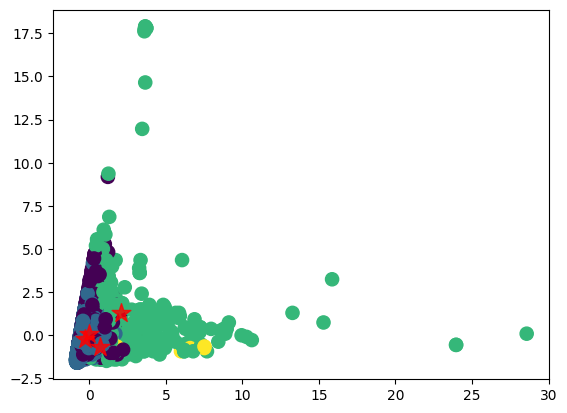

In [ ]:
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans.fit(X_scaled)
y_kmeans = kmeans.predict(X_scaled)

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_kmeans, s=90, cmap='viridis')

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.8, marker='*')

Menghitung Silhouette Score...
Untuk k=2, Silhouette Score = 0.3323
Untuk k=3, Silhouette Score = 0.0648
Untuk k=4, Silhouette Score = 0.0785
Untuk k=5, Silhouette Score = 0.0611
Untuk k=6, Silhouette Score = 0.0682
Untuk k=7, Silhouette Score = 0.0726
Untuk k=8, Silhouette Score = 0.0747
Untuk k=9, Silhouette Score = 0.0387


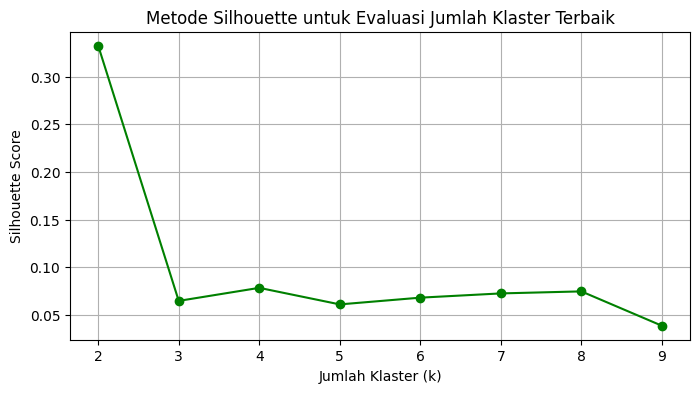

In [ ]:
sil_scores = []
K_sil = range(2, 10) # Range k=2 hingga k=9

print("Menghitung Silhouette Score...")
for k in K_sil:
    # Inisialisasi dan latih model
    kmeans_sil = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans_sil.fit_predict(X_scaled)

    # Hitung skor (tambahkan parameter sample_size=10000 jika data Anda yang 783k dipakai lagi)
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)

    print(f"Untuk k={k}, Silhouette Score = {score:.4f}")

# Memvisualisasikan hasil
plt.figure(figsize=(8, 4))
plt.plot(K_sil, sil_scores, "go-")
plt.xlabel("Jumlah Klaster (k)")
plt.ylabel("Silhouette Score")
plt.title("Metode Silhouette untuk Evaluasi Jumlah Klaster Terbaik")
plt.grid(True)
plt.show()